In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
from sklearn import set_config

from sksurv.linear_model import CoxnetSurvivalAnalysis
from sklearn.model_selection import train_test_split
set_config(display="text")  # displays text representation of estimators

from sksurv.util import Surv
sys.path.append(os.path.abspath("../../"))
from src.utils.ConvertTextToCsv import TextToCsv
from src.utils.Preprocessing import Preprocessor
from src.utils.cox_models import Cox_regression, p_values_Cox_regression, plot_coefficients
%load_ext autoreload
%autoreload 2
%matplotlib inline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
pp = Preprocessor()
cox_lasso = CoxnetSurvivalAnalysis(l1_ratio=1.0, alpha_min_ratio=0.01)
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_keep = pp.clean_columns_dataset(df_clinical_data)


<font size="4">Preprocessing</font>

In [15]:
list_df = pp.total_type_len_type_cancer(df_clinical_keep)
df_clinical_keep["Tumor-Cancer"] = list_df
df_mRNA_transformed = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")
clean_df = pp.elimnation_zeros(df_mRNA_transformed, "Hugo_Symbol")

Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 298 - Total(%) 0.36
Shape of the CSV: (20440, 819)
Max of zeros per row in the dataset: 4575
Avg of zeros per row in the dataset: 2911.273838630807
Median of zeros per row in the dataset: 2866.5
Min of zeros per row in the dataset: 0
After the 0 elimination: 454


<font size="4">ESR1 coefficients and p_values</font>

In [16]:
df_ESR1 = pp.gene_to_long(clean_df,"ESR1")

In [17]:
df_ESR1_merged = df_ESR1.merge(df_clinical_keep, on="Sample ID", how="inner")
status = df_ESR1_merged["Overall Survival Status"].astype(str).str.strip()
df_ESR1_merged["event"] = status.str.contains("DECEASED", na=False) 
df_ESR1_merged = df_ESR1_merged.dropna(subset=["Overall Survival (Months)"])
X_ESR1 = df_ESR1_merged[["expression"]]
Y_surv_ESR1 = Surv.from_dataframe(
    event="event",
    time="Overall Survival (Months)",
    data=df_ESR1_merged
)

In [18]:
X_train_ESR1, X_test_ESR1, Y_train_ESR1, Y_test_ESR1 = train_test_split(
    X_ESR1, Y_surv_ESR1, train_size=0.80, test_size=0.20, random_state=42
)


In [19]:
betas_ESR1, chp_predict_ESR1, survival_curve_ESR1, risk_curve_ESR1 = Cox_regression(X_train_ESR1, Y_train_ESR1, X_test_ESR1)

In [20]:
print(betas_ESR1)
#Alpha is regularization 
#Low alpha == Low regularization
#Big alpha == Big regularization

#Espression == Betas 
#β > 0 → aumenta el riesgo
#β < 0 → reduce el riesgo
#β ≈ 0 → no hay efecto

alpha       0.00010      0.00015      0.00021      0.00031      0.00045      \
expression    -0.000004    -0.000004    -0.000004    -0.000004    -0.000004   

alpha       0.00066      0.00095      0.00139      0.00202      0.00295      \
expression    -0.000004    -0.000004    -0.000004    -0.000004    -0.000004   

alpha       ...  339.32218    494.17134    719.68567    1048.11313   \
expression  ...    -0.000004    -0.000004    -0.000004    -0.000004   

alpha       1526.41797   2222.99648   3237.45754   4714.86636   6866.48845   \
expression    -0.000004    -0.000004    -0.000004    -0.000004    -0.000004   

alpha       10000.00000  
expression    -0.000004  

[1 rows x 50 columns]


In [21]:
print(chp_predict_ESR1)

# Risk Score = Expression x β
# valor más alto → mayor riesgo relativo
#valor más bajo → menor riesgo relativo

[-1.11913345e-01 -8.29724822e-02 -2.55550245e-02 -2.59254334e-02
 -9.08697688e-02 -1.07524525e-01 -2.68978647e-02 -9.92847531e-02
 -5.73786409e-02 -4.32493769e-02 -4.92485410e-02 -4.80035186e-02
 -5.65868129e-02 -9.73298147e-04 -4.52104017e-03 -6.41825361e-02
 -1.76414387e-02 -4.78584334e-02 -3.23083008e-01 -5.06360425e-02
 -5.08319931e-04 -1.12844306e-02 -3.23505188e-03 -1.13626371e-01
 -2.03960278e-04 -1.13316913e-03 -4.56748358e-02 -1.00659733e-02
 -6.71147772e-02 -1.45152479e-01 -1.71665141e-01 -5.89058108e-02
 -2.43573192e-03 -1.13015713e-01 -2.84549337e-02 -8.89708787e-02
 -2.72502609e-02 -1.16782328e-01 -2.39971649e-02 -3.33182253e-02
 -4.22355906e-02 -2.86613178e-02 -3.91710175e-02 -1.08994400e-01
 -7.89093770e-02 -4.30719059e-04 -1.04015682e-01 -2.22601528e-02
 -3.92305501e-03 -4.20723103e-02 -3.77170724e-04 -2.11507789e-04
 -2.32093594e-02 -1.74655166e-01 -3.49872677e-02 -1.27388001e-02
 -5.79033924e-04 -1.81271582e-02 -4.51013527e-03 -6.22043509e-02
 -2.67296754e-02 -4.36008

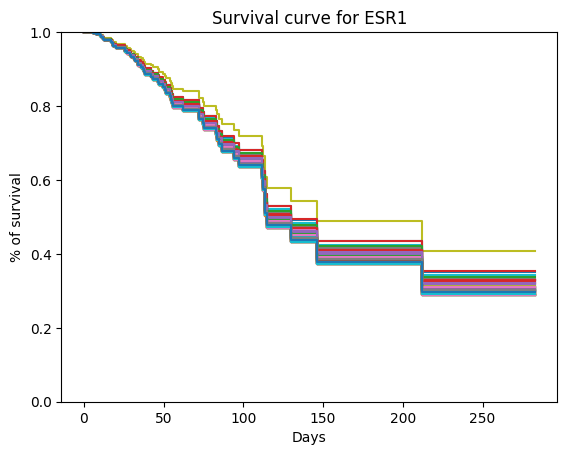

In [22]:
for fn in survival_curve_ESR1:
    plt.step(fn.x, fn(fn.x), where="post")

plt.title("Survival curve for ESR1")
plt.xlabel("Days")
plt.ylim(0, 1)
plt.ylabel("% of survival")
plt.show()

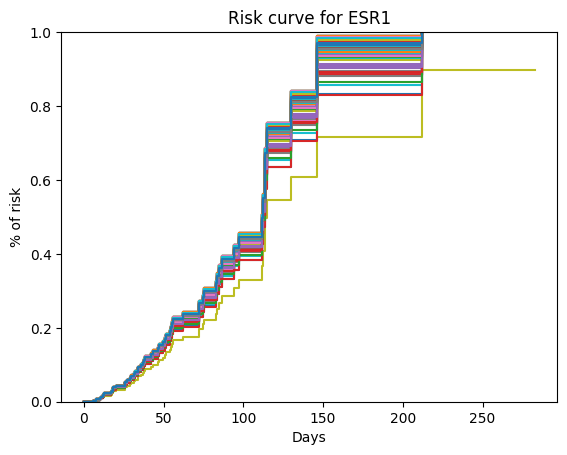

In [23]:
for fn in risk_curve_ESR1:
    plt.step(fn.x, fn(fn.x), where="post")

plt.title("Risk curve for ESR1")
plt.xlabel("Days")
plt.ylim(0, 1)
plt.ylabel("% of risk")
plt.show()

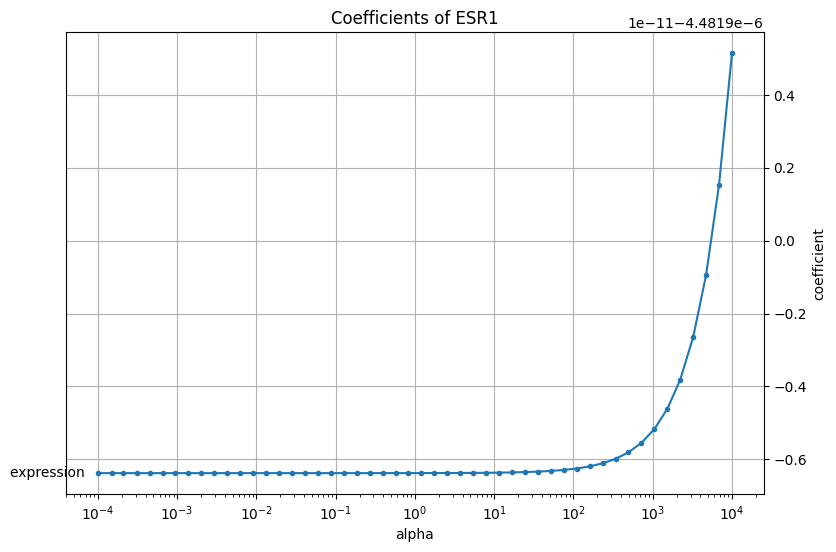

In [24]:
plot_coefficients(betas_ESR1, n_highlight=5, title="Coefficients of ESR1")

In [25]:
"""cox_lasso.fit(X_train_ESR1, X_test_ESR1)
coefficient_lasso = pd.DataFrame(cox_lasso.coef_, index=X.columns, columns=(cox_lasso.alphas_))
plot_coefficients(coefficient_lasso, n_highlight=5, title="ESR1 Coefficients")
cox_lasso.predict(X_test)
"""

'cox_lasso.fit(X_train_ESR1, X_test_ESR1)\ncoefficient_lasso = pd.DataFrame(cox_lasso.coef_, index=X.columns, columns=(cox_lasso.alphas_))\nplot_coefficients(coefficient_lasso, n_highlight=5, title="ESR1 Coefficients")\ncox_lasso.predict(X_test)\n'

In [26]:
df_life_line_ESR1 = df_ESR1_merged[["expression", "event", "Overall Survival (Months)"]]

In [27]:
p_values_Cox_regression(df_life_line_ESR1,event_col="event", duration_col="Overall Survival (Months)")

#p_values = p
#p < 0.05 → hay evidencia de que la variable sí afecta la supervivencia
#p ≥ 0.05 → no hay evidencia suficiente
# p == 0.79 = No significativo

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
expression,-0.000004,0.999996,0.000015,-0.000033,0.000025,0.999967,1.000025,0.0,-0.257217,0.797011,0.327328


<font size="4">AURKA coefficients and p_values</font>

In [ ]:
df_AURKA = pp.gene_to_long(clean_df, "AURKA")

NameError: name 'clean_df' is not defined

In [ ]:
df_AURKA_merged = df_AURKA.merge(df_clinical_keep, on="Sample ID", how="inner")
status = df_AURKA_merged["Overall Survival Status"].astype(str).str.strip()
df_AURKA_merged["event"] = status.str.contains("DECEASED", na=False) 
df_AURKA_merged = df_AURKA_merged.dropna(subset=["Overall Survival (Months)"])
X_AURKA = df_AURKA_merged[["expression"]]
Y_surv_AURKA = Surv.from_dataframe(
    event="event",
    time="Overall Survival (Months)",
    data=df_AURKA_merged
)

In [ ]:
X_train_AURKA, X_test_AURKA, Y_train_AURKA, Y_test_AURKA = train_test_split(
    X_AURKA, Y_surv_AURKA, train_size=0.80, test_size=0.20, random_state=42
)


In [ ]:
betas_AURKA, chp_predict_AURKA, survival_curve_AURKA, risk_curve_AURKA = Cox_regression(X_train_AURKA, Y_train_AURKA, X_test_AURKA)

In [ ]:
print(betas_AURKA)
#Alpha is regularization 
#Low alpha == Low regularization
#Big alpha == Big regularization

#Espression == Betas 
#β > 0 → aumenta el riesgo
#β < 0 → reduce el riesgo
#β ≈ 0 → no hay efecto

In [ ]:
print(chp_predict_AURKA)

# Risk Score = Expression x β
# valor más alto → mayor riesgo relativo
#valor más bajo → menor riesgo relativo

In [ ]:
for fn in survival_curve_AURKA:
    plt.step(fn.x, fn(fn.x), where="post")

plt.title("Survival curve for AURKA")
plt.xlabel("Days")
plt.ylim(0, 1)
plt.ylabel("% of survival")
plt.show()

In [ ]:
for fn in risk_curve_AURKA:
    plt.step(fn.x, fn(fn.x), where="post")

plt.title("Risk curve for AURKA")
plt.ylim(0, 1)
plt.xlabel("Days")
plt.ylabel("% of survival")
plt.show()

In [ ]:
plot_coefficients(betas_AURKA, n_highlight=5, title="Coefficients of ESR1")

In [ ]:
df_life_line_AURKA = df_AURKA_merged[["expression", "event", "Overall Survival (Months)"]]

In [ ]:
p_values_Cox_regression(df_life_line_AURKA,event_col="event", duration_col="Overall Survival (Months)")

#p_values = p
#p < 0.05 → hay evidencia de que la variable sí afecta la supervivencia
#p ≥ 0.05 → no hay evidencia suficiente
# p == 0.61 = No significativo

<font size="4">Luminal A betas and p_values</font>

In [2]:
pp = Preprocessor()
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_keep = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_keep)
df_clinical_keep["Tumor-Cancer"] = list_df
df_mRNA_transformed = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")
df_merged = pp.merge_datasets(df_clinical_keep, df_mRNA_transformed)

Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 298 - Total(%) 0.36
Shape of the CSV: (20440, 819)


In [3]:
expressions_genes_cols = df_merged.iloc[1:20441].sample(650, axis="columns")
cols = ["Tumor-Cancer", "Overall Survival Status", "Overall Survival (Months)"] + list(expressions_genes_cols)

comparation_df = df_merged.loc[
    df_merged["Tumor-Cancer"].isin(["Luminal A", "Luminal B", "TNBC", "HER2-enriched"]),
    cols
]

comparation_df

,Tumor-Cancer,Overall Survival Status,Overall Survival (Months),15384,4125,4760,677,16635,10904,15307,...,11264,18422,12083,16102,19229,4849,4453,6458,7067,15285
2,Luminal A,0:LIVING,43.400000,5.9235,2869.2719,642.3694,547.9227,0.0,6.9107,0.0000,...,326.7988,2288.7701,843.0967,617.0300,1142.2460,0.0000,22.3776,528.5068,488.3587,2126.5323
6,Luminal A,0:LIVING,13.670000,11.7055,3214.9977,439.6891,734.8880,0.0,0.7316,0.3658,...,225.8985,908.6420,540.2835,450.6630,1240.0549,0.3658,4.3896,196.4335,276.5432,1982.9904
7,TNBC,1:DECEASED,31.770000,0.9455,1557.8317,381.0274,468.6417,0.0,1.2606,0.0000,...,392.7041,991.8059,2919.6281,61.7712,1647.9672,7.5638,6.3032,335.3293,63.3470,2344.7841
8,Luminal B,0:LIVING,7.950000,0.6313,2761.3636,897.0960,1095.9596,0.0,0.0000,0.0000,...,228.0871,1593.4343,475.6944,466.8561,1285.3535,0.0000,9.1540,89.6465,946.6540,2042.2980
10,TNBC,0:LIVING,19.190000,6.5669,2623.4951,578.9858,505.6549,0.0,207.9533,0.0000,...,371.1638,1763.2251,4431.5724,708.8654,714.7027,4.7428,16.0525,208.3181,157.9715,1792.0467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
812,Luminal A,0:LIVING,22.370000,13.0412,2615.0235,1340.6364,658.3203,0.0,3.6515,0.0000,...,170.4851,1270.2139,623.3698,396.4528,2967.1362,0.0000,35.9937,332.8117,684.9244,1648.4090
813,Luminal A,0:LIVING,26.695598,2.0851,2522.5188,3684.7373,472.0601,0.0,0.8340,0.0000,...,384.6372,1111.7598,499.5830,20.8507,3342.3686,0.8340,80.4837,343.6197,138.8657,2245.6214
814,TNBC,0:LIVING,23.460000,0.8346,1631.2989,1276.5780,508.7115,0.0,1.6693,0.0000,...,258.1575,813.3542,2647.0527,344.2879,1347.9395,4.1732,32.1335,174.8565,339.2801,1294.9400
815,Luminal A,0:LIVING,65.570000,27.9405,2353.7630,609.7341,550.2479,0.0,99.1438,0.0000,...,180.1442,1004.9572,431.4511,117.1699,2819.2880,0.9013,59.0356,427.2195,334.3849,1952.6814


In [4]:
comparation_df = pp.elimnation_zeros(comparation_df, "Tumor-Cancer")

Max of zeros per row in the dataset: 519
Avg of zeros per row in the dataset: 75.10276073619632
Median of zeros per row in the dataset: 0.0
Min of zeros per row in the dataset: 0
After the 0 elimination: 518


In [5]:
luminal_A_df = comparation_df[comparation_df["Tumor-Cancer"] == "Luminal A"]
status = luminal_A_df["Overall Survival Status"].astype(str).str.strip()
luminal_A_df["event"] = status.str.contains("DECEASED", na=False) 
luminal_A_df = luminal_A_df.dropna(subset=["Overall Survival (Months)"])
X_LUMINAL_A = luminal_A_df.iloc[:, 3:-1]
Y_surv_LUMINAL_A = Surv.from_dataframe(
    event="event",
    time="Overall Survival (Months)",
    data=luminal_A_df
)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [ ]:

X_train_LuminalA, X_test_LuminalA,Y_train_LuminalA,Y_test_LuminalA = train_test_split(
    X_LUMINAL_A, Y_surv_LUMINAL_A, train_size=0.80, test_size=0.20, random_state=42
)


    
    

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [10]:

for i, X_train_sample in enumerate(zip(X_train_LuminalA, Y_train_LuminalA)):
    print(i)
#betas_LuminalA, chp_predict_LuminalA, survival_curve_LuminalA, risk_curve_LuminalA = Cox_regression(X_train_LuminalA, Y_train_LuminalA, X_test_LuminalA)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263


In [11]:
for fn in survival_curve_LuminalA:
    plt.step(fn.x, fn(fn.x), where="post")

plt.title("Survival curve for ESR1")
plt.xlabel("Days")
plt.ylim(0, 1)
plt.ylabel("% of survival")
plt.show()

NameError: name 'survival_curve_LuminalA' is not defined

In [ ]:
for fn in risk_curve_LuminalA:
    plt.step(fn.x, fn(fn.x), where="post")

plt.title("Survival curve for Luminal A")
plt.xlabel("Days")
plt.ylim(0, 1)
plt.ylabel("% of survival")
plt.show()

In [28]:
expressions_luminal_A = luminal_A_df.iloc[:, 3:-1]

In [71]:
i = 0
p_values = []
for i, sample in enumerate(expressions_luminal_A.columns):
    df_life_line_sample = luminal_A_df[
        [sample, "event", "Overall Survival (Months)"]
    ]
    p_values.append(p_values_Cox_regression(df_life_line_sample,event_col="event", duration_col="Overall Survival (Months)"))

    if i > 50:
        break 

In [85]:
df_final = pd.concat(p_values)

df_final[["coef","exp(coef)", "exp(coef)","z", "p"]]

,coef,exp(coef),exp(coef),z,p
covariate,,,,,
15384,-0.034825,0.965775,0.965775,-1.264783,0.205949
4125,0.000035,1.000035,1.000035,0.190611,0.848830
4760,-0.000372,0.999628,0.999628,-1.183516,0.236605
677,-0.002013,0.997989,0.997989,-1.336474,0.181394
19291,-0.000137,0.999863,0.999863,-0.297489,0.766093
14788,-0.055913,0.945622,0.945622,-0.564221,0.572604
17907,-0.005816,0.994201,0.994201,-1.367807,0.171373
10004,-0.008697,0.991341,0.991341,-1.053044,0.292321
4173,-0.000110,0.999890,0.999890,-0.123808,0.901467


<font size="4">Luminal B, TNBC, Her-Enriched2 betas and p_values</font>

In [ ]:
diff_subtypes_df = comparation_df[comparation_df["Tumor-Cancer"] != "Luminal A"]
status = diff_subtypes_df["Overall Survival Status"].astype(str).str.strip()
diff_subtypes_df["event"] = status.str.contains("DECEASED", na=False) 
diff_subtypes_df = diff_subtypes_df.dropna(subset=["Overall Survival (Months)"])
X_diff_subtypes = diff_subtypes_df.iloc[:, 3:-1]
Y_surv_subtypes = Surv.from_dataframe(
    event="event",
    time="Overall Survival (Months)",
    data=diff_subtypes_df
)
